### This notebook contains a detailed description of the dataset along with relevant statistical summaries.

In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))
from deep_gp.preprocessing_data import load_data, undersample_class0, apply_smote

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
data = load_data()
df_new = undersample_class0(data)
df_resampled = apply_smote(df_new)

X_balanced = df_resampled.drop(columns=["case_ISUP"])
y_balanced = df_resampled["case_ISUP"]


In [3]:
# Count of study_ids per ISUP grade in the original dataset
print("\n Original class counts ")
counts = data["case_ISUP"].value_counts().sort_index()
print(counts)


 Original class counts 
case_ISUP
0    589
1    157
2    154
3     69
4     27
5     35
Name: count, dtype: int64


In [4]:
print(len(data['study_id']))

1031


In [5]:
print("\nFinal class counts AFTER Undersampling class 0 and SMOTE:")
print(df_resampled["case_ISUP"].value_counts().sort_index())


Final class counts AFTER Undersampling class 0 and SMOTE:
case_ISUP
0    262
1    157
2    154
3    150
4    150
5    150
Name: count, dtype: int64


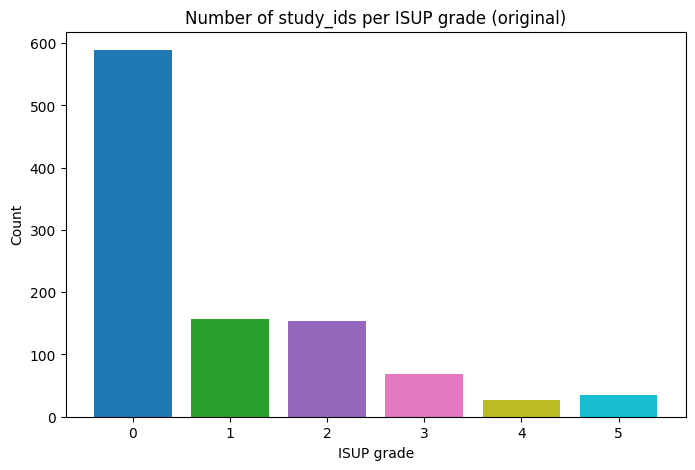

In [6]:
# Example: counts is a pandas Series with ISUP grades as index
# counts.index → ISUP grades
# counts.values → counts per grade


colors = plt.cm.tab10(np.linspace(0, 1, len(counts)))

plt.figure(figsize=(8, 5))
plt.bar(counts.index, counts.values, color=colors)

plt.title("Number of study_ids per ISUP grade (original)")
plt.xlabel("ISUP grade")
plt.ylabel("Count")

plt.show()


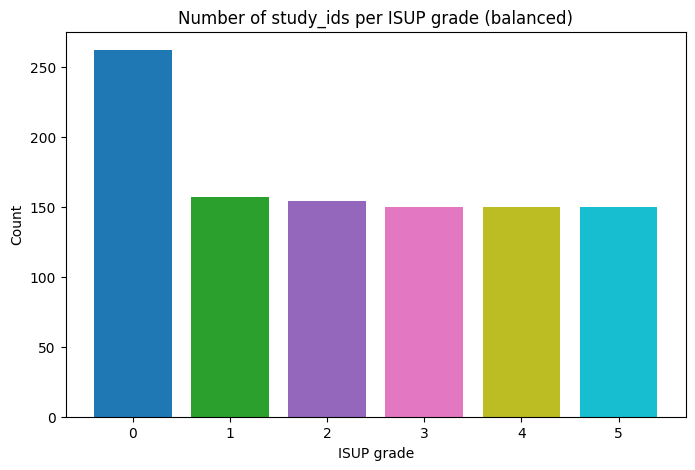

In [7]:
# Count the occurrences of each ISUP class after undersampling class 0 and SMOTE
counts_bal = df_resampled["case_ISUP"].value_counts().sort_index()

colors = plt.cm.tab10(np.linspace(0, 1, len(counts_bal)))

plt.figure(figsize=(8, 5))
plt.bar(counts_bal.index, counts_bal.values, color=colors)

plt.title("Number of study_ids per ISUP grade (balanced)")
plt.xlabel("ISUP grade")

plt.ylabel("Count")

plt.show()


In [8]:
# Correlation of predictors with ISUP grade
y_balanced = df_resampled["case_ISUP"].astype(int)
corrs = X_balanced.corrwith(y_balanced, method='spearman').sort_values(key=abs, ascending=False)

print(corrs.head(20))

original_firstorder_Minimum                           0.206413
original_shape_Sphericity                            -0.183850
original_shape_SurfaceVolumeRatio                     0.166361
original_gldm_LargeDependenceHighGrayLevelEmphasis    0.155700
original_gldm_DependenceEntropy                       0.137015
original_ngtdm_Strength                               0.136132
original_shape_LeastAxisLength                       -0.127305
original_ngtdm_Coarseness                             0.125283
original_glrlm_LongRunHighGrayLevelEmphasis           0.121773
original_gldm_SmallDependenceLowGrayLevelEmphasis    -0.118655
original_glszm_SmallAreaLowGrayLevelEmphasis         -0.115526
original_glcm_Imc2                                    0.115274
original_shape_MeshVolume                            -0.113116
original_shape_VoxelVolume                           -0.113049
original_shape_MinorAxisLength                       -0.111295
original_shape_MajorAxisLength                       -0

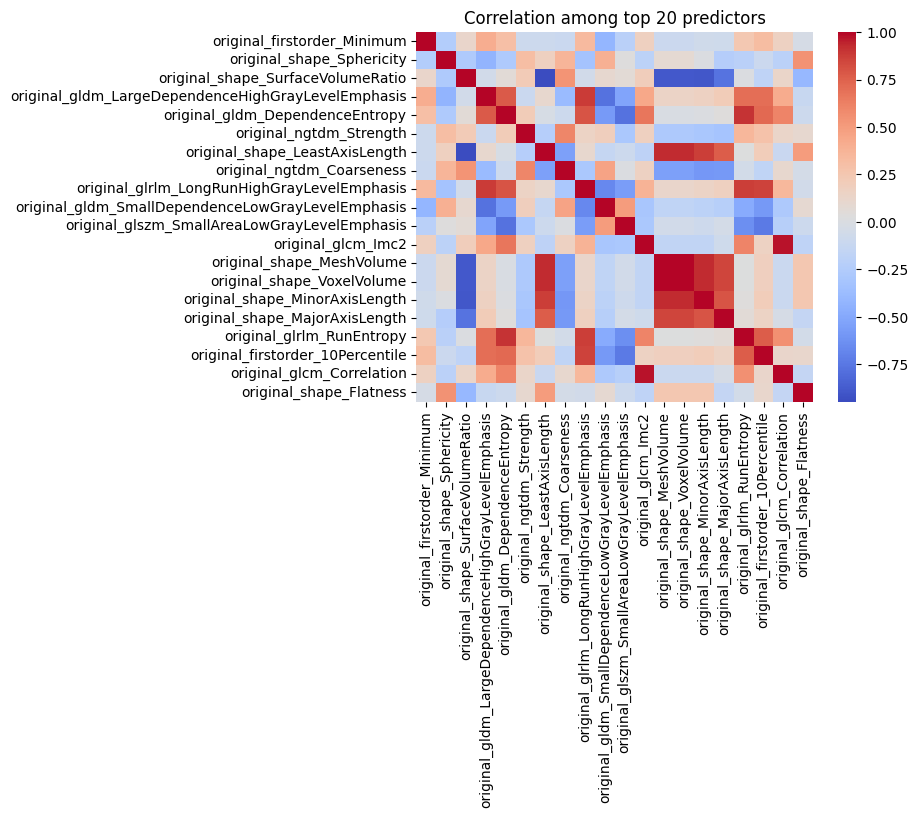

In [9]:
# Heatmap of top 20 correlated predictors
top_predictors = corrs.head(20).index
sns.heatmap(pd.DataFrame(X_balanced, columns=X_balanced.columns)[top_predictors].corr(),
            cmap="coolwarm")
plt.title("Correlation among top 20 predictors")
plt.show()

In [10]:
predictor_cols = [
    col for col in data.columns
    if col not in ["case_ISUP", "patient_id", "study_id"]
]

# Statistics on the original dataset

predictor_stats_orig = (
    data.groupby("case_ISUP")[predictor_cols]
        .agg([
            "mean",
            "median",
            "std",
            "min",
            "max",
            ("q25", lambda x: x.quantile(0.25)),
            ("q75", lambda x: x.quantile(0.75))
        ])
)

print(predictor_stats_orig)


          original_shape_Elongation                                          \
                               mean    median       std       min       max   
case_ISUP                                                                     
0                          0.881161  0.897260  0.076314  0.586025  0.996473   
1                          0.855626  0.874988  0.086619  0.643241  0.992448   
2                          0.852903  0.863867  0.086276  0.399072  0.973635   
3                          0.866995  0.881706  0.075164  0.700211  0.981705   
4                          0.850365  0.837429  0.070938  0.702276  0.978886   
5                          0.881120  0.887666  0.068189  0.663479  0.992628   

                              original_shape_Flatness                      \
                q25       q75                    mean    median       std   
case_ISUP                                                                   
0          0.836036  0.939819                0.734196  0.

In [11]:
predictor_cols_bal = [
    col for col in df_resampled.columns
    if col not in ["case_ISUP", "patient_id", "study_id"]
]

# Statistics on the balanced dataset
predictor_stats_bal = (
    df_resampled.groupby("case_ISUP")[predictor_cols_bal]
        .agg([
            "mean",
            "median",
            "std",
            "min",
            "max",
            ("q25", lambda x: x.quantile(0.25)),
            ("q75", lambda x: x.quantile(0.75))
        ])
)

print(predictor_stats_bal)


          original_shape_Elongation                                          \
                               mean    median       std       min       max   
case_ISUP                                                                     
0                          0.883185  0.900922  0.073513  0.586025  0.996473   
1                          0.855626  0.874988  0.086619  0.643241  0.992448   
2                          0.852903  0.863867  0.086276  0.399072  0.973635   
3                          0.866706  0.879718  0.068672  0.700211  0.981705   
4                          0.866814  0.867195  0.055617  0.702276  0.978886   
5                          0.879767  0.880945  0.057023  0.663479  0.992628   

                              original_shape_Flatness                      \
                q25       q75                    mean    median       std   
case_ISUP                                                                   
0          0.842106  0.936427                0.731345  0.